In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
base_path = r"C:\Users\FATIMA\OneDrive\Documents\plant_disease_project\dataset"

train_dir = os.path.join(base_path, "train")
val_dir   = os.path.join(base_path, "val")
test_dir  = os.path.join(base_path, "test")

In [3]:
def get_class_distribution(folder):
    class_counts = {}

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            count = 0
            for file in os.listdir(class_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    count += 1
            class_counts[class_name] = count

    return class_counts

In [4]:
train_dist = get_class_distribution(train_dir)
val_dist   = get_class_distribution(val_dir)
test_dist  = get_class_distribution(test_dir)

In [5]:
def plot_distribution(dist, title):
    plt.figure(figsize=(14,6))
    plt.bar(dist.keys(), dist.values())
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.ylabel("Number of Images")
    plt.tight_layout()
    plt.show()

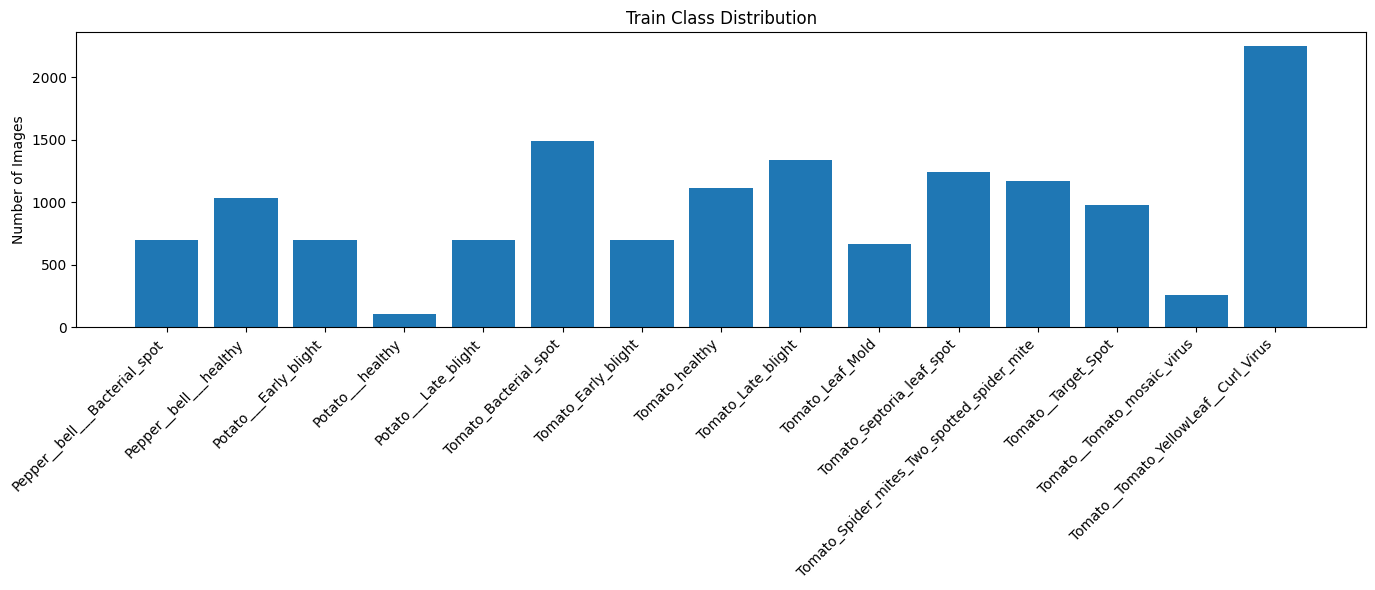

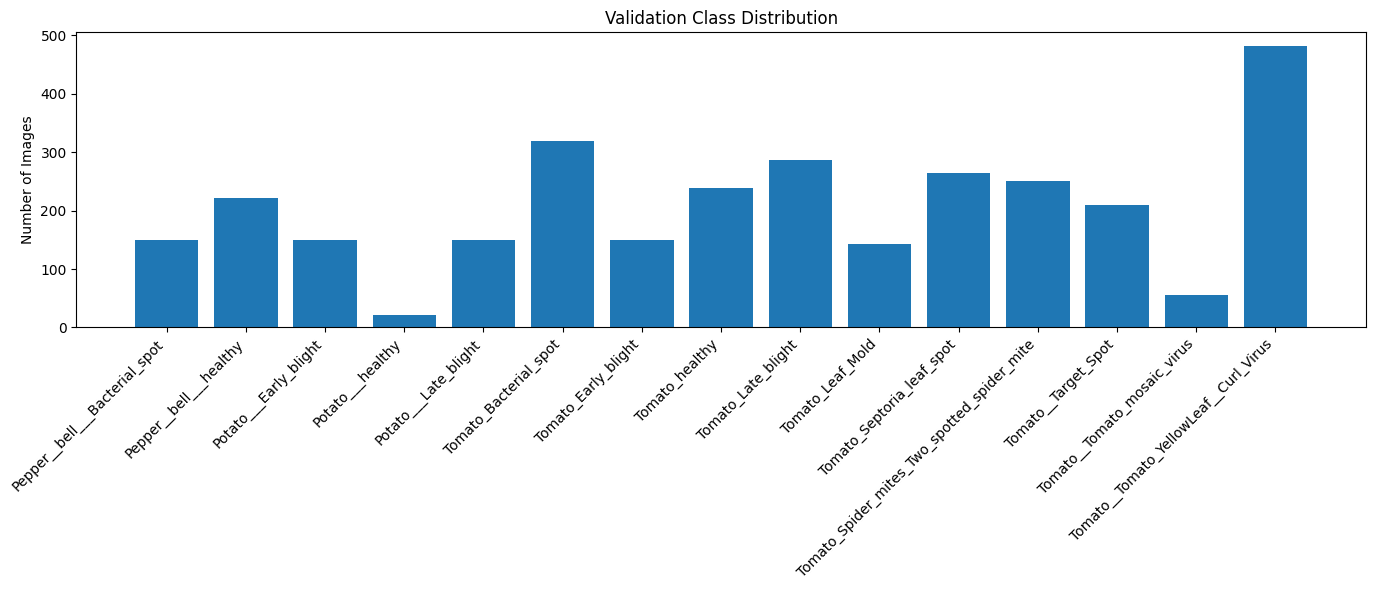

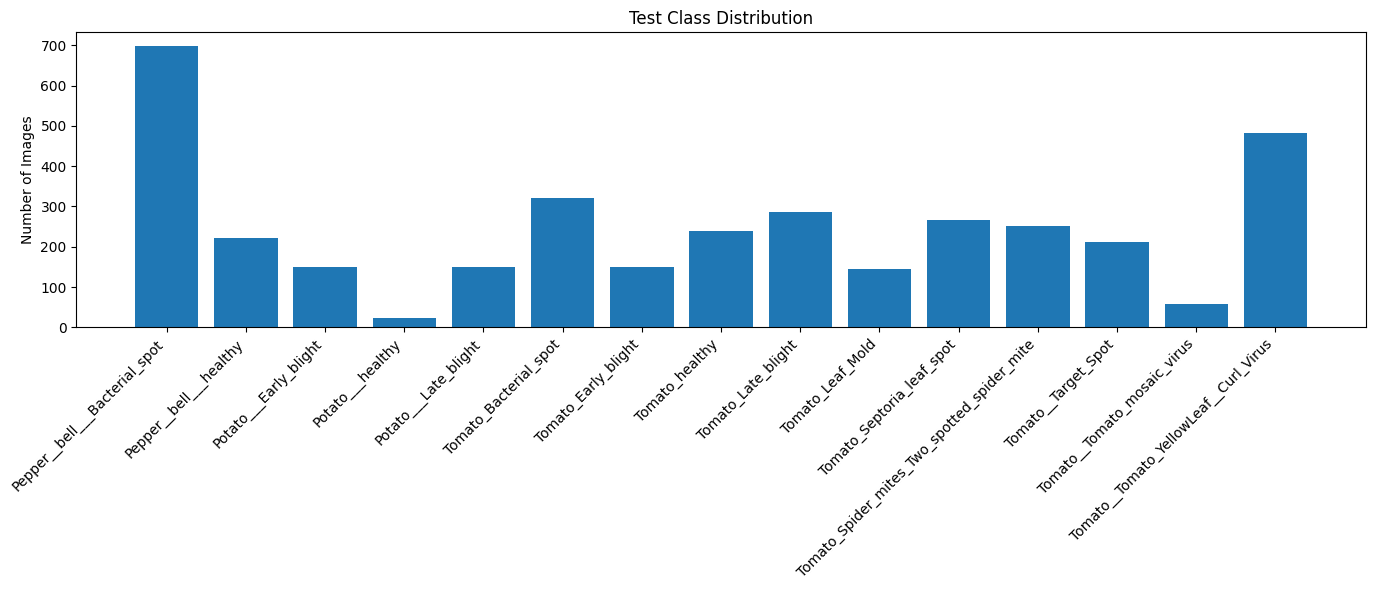

In [6]:
plot_distribution(train_dist, "Train Class Distribution")
plot_distribution(val_dist, "Validation Class Distribution")
plot_distribution(test_dist, "Test Class Distribution")

In [7]:
df_dist = pd.DataFrame.from_dict(train_dist, orient='index', columns=['count'])
df_dist = df_dist.sort_values(by='count', ascending=False)

print("Top 5 classes:\n", df_dist.head())
print("\nLeast 5 classes:\n", df_dist.tail())

print("\nMin images:", df_dist['count'].min())
print("Max images:", df_dist['count'].max())
print("Imbalance ratio:", df_dist['count'].max() / df_dist['count'].min())

Top 5 classes:
                                              count
Tomato__Tomato_YellowLeaf__Curl_Virus         2245
Tomato_Bacterial_spot                         1488
Tomato_Late_blight                            1336
Tomato_Septoria_leaf_spot                     1239
Tomato_Spider_mites_Two_spotted_spider_mite   1173

Least 5 classes:
                                count
Tomato_Early_blight              700
Pepper__bell___Bacterial_spot    697
Tomato_Leaf_Mold                 666
Tomato__Tomato_mosaic_virus      261
Potato___healthy                 106

Min images: 106
Max images: 2245
Imbalance ratio: 21.17924528301887


In [8]:
def analyze_images(folder):
    widths = []
    heights = []
    aspect_ratios = []

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)

                if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                try:
                    img = cv2.imread(img_path)
                    if img is not None:
                        h, w, _ = img.shape
                        widths.append(w)
                        heights.append(h)
                        aspect_ratios.append(w / h)
                except:
                    pass

    return widths, heights, aspect_ratios

In [9]:
w1, h1, ar1 = analyze_images(train_dir)
w2, h2, ar2 = analyze_images(val_dir)
w3, h3, ar3 = analyze_images(test_dir)

widths = w1 + w2 + w3
heights = h1 + h2 + h3
aspect_ratios = ar1 + ar2 + ar3

In [10]:
df = pd.DataFrame({
    "Width": widths,
    "Height": heights,
    "Aspect_Ratio": aspect_ratios
})

In [11]:
print("Width Stats:\n", df["Width"].describe())
print("\nHeight Stats:\n", df["Height"].describe())
print("\nAspect Ratio Stats:\n", df["Aspect_Ratio"].describe())

Width Stats:
 count    21184.0
mean       256.0
std          0.0
min        256.0
25%        256.0
50%        256.0
75%        256.0
max        256.0
Name: Width, dtype: float64

Height Stats:
 count    21184.0
mean       256.0
std          0.0
min        256.0
25%        256.0
50%        256.0
75%        256.0
max        256.0
Name: Height, dtype: float64

Aspect Ratio Stats:
 count    21184.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: Aspect_Ratio, dtype: float64


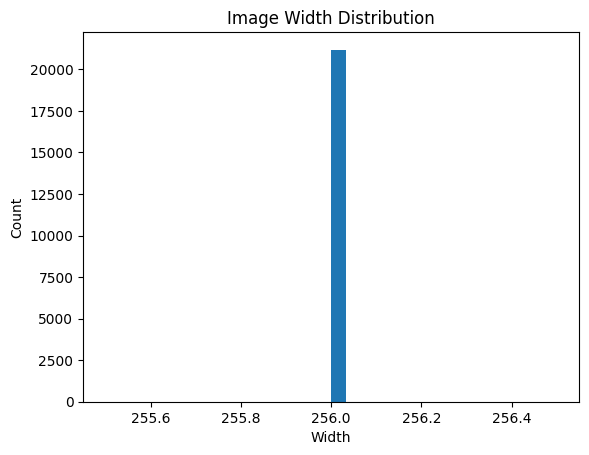

In [12]:
plt.hist(df["Width"], bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Count")
plt.show()

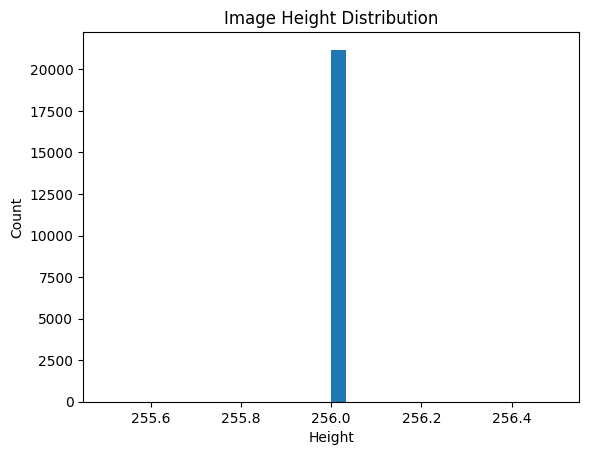

In [13]:
plt.hist(df["Height"], bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

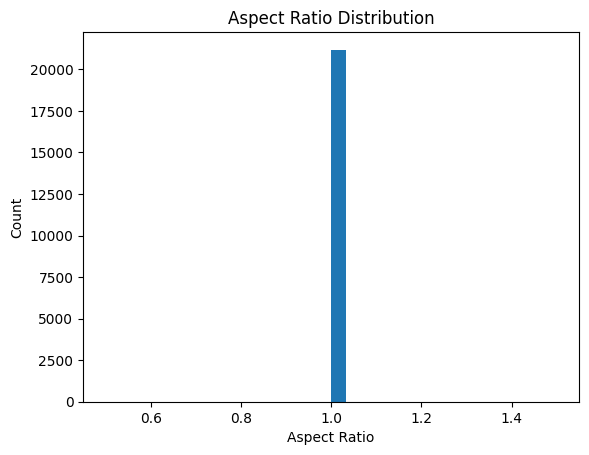

In [14]:
plt.hist(df["Aspect_Ratio"], bins=30)
plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Count")
plt.show()

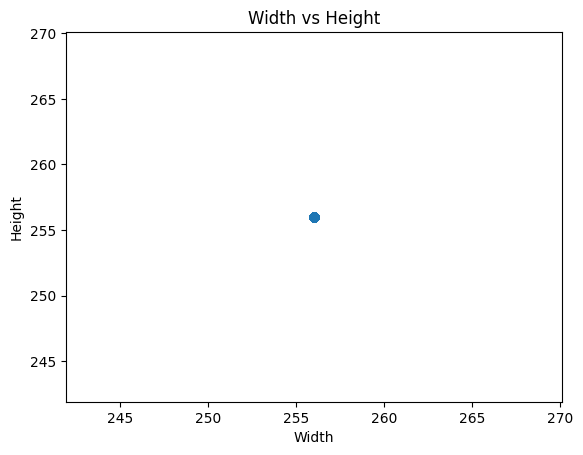

In [15]:
plt.scatter(df["Width"], df["Height"], alpha=0.3)
plt.title("Width vs Height")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

### Observations:

1. Class Distribution:
   - Dataset shows class imbalance.
   - Some classes have significantly more images than others.
   - Imbalance ratio ≈ (max/min value).

2. Image Resolution:
   - Images vary in width and height.
   - Not all images have same resolution.

3. Aspect Ratio:
   - Most images have aspect ratio close to 1.
   - Some variation exists.

### Conclusion:
- Image resizing to 224x224 is required.
- Data augmentation is useful for generalization.
- Class imbalance handling (WeightedSampler) is necessary.